# Camera Calibration — Practice on REAL Images (OpenCV)

Unlike a synthetic `projectPoints` demo, this notebook runs the full calibration
pipeline on the **real OpenCV stereo chessboard image set** (`left*.jpg` / `right*.jpg`,
640×480, a genuine 8.4 cm-baseline stereo rig).

| Step | OpenCV function | Real data |
|---|---|---|
| 1. Corner detection | `findChessboardCorners` + `cornerSubPix` | 13 real photos |
| 2. Intrinsic calibration | `calibrateCamera` | → K, distortion, RMS ~0.4 px |
| 3. Undistortion | `undistort` | lens distortion removed |
| 4. Extrinsic pose | `solvePnP` | board → camera [R\|t] |
| 5. Stereo calibration | `stereoCalibrate` | left↔right R, T |
| 6. Rectification | `stereoRectify` + `remap` | rows aligned for 1-D search |
| 7. Disparity → depth | `StereoSGBM`, Z=fB/d | metric depth |

Images live in `data/chessboard/` (downloaded from the OpenCV sample repo, ~744 KB).


In [1]:
import cv2, glob, os
import numpy as np
import matplotlib.pyplot as plt

DATA = 'data/chessboard'

# Auto-download the OpenCV sample images if they are not present
if not glob.glob(f'{DATA}/left*.jpg'):
    import urllib.request
    os.makedirs(DATA, exist_ok=True)
    base = 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data'
    for i in [f'{n:02d}' for n in range(1, 15)]:
        for side in ('left', 'right'):
            try:
                urllib.request.urlretrieve(f'{base}/{side}{i}.jpg', f'{DATA}/{side}{i}.jpg')
            except Exception:
                pass

left_imgs  = sorted(glob.glob(f'{DATA}/left*.jpg'))
right_imgs = sorted(glob.glob(f'{DATA}/right*.jpg'))
H, W = cv2.imread(left_imgs[0]).shape[:2]
IMG_SIZE = (W, H)   # OpenCV uses (width, height)
print(f'Left images : {len(left_imgs)}')
print(f'Right images: {len(right_imgs)}')
print(f'Image size  : {W}x{H}')


Left images : 13
Right images: 13
Image size  : 640x480


## 1. Corner Detection on Real Photos

`findChessboardCorners` locates the inner-corner grid; `cornerSubPix` refines each
corner to sub-pixel accuracy. The board has **9×6 inner corners** with 25 mm squares.

> Note: the physical square size (25 mm) is an assumption. It only scales the
> *extrinsic* translation and stereo baseline — the intrinsics K and the rectification
> are completely independent of it.


Corners found in 13/13 left images


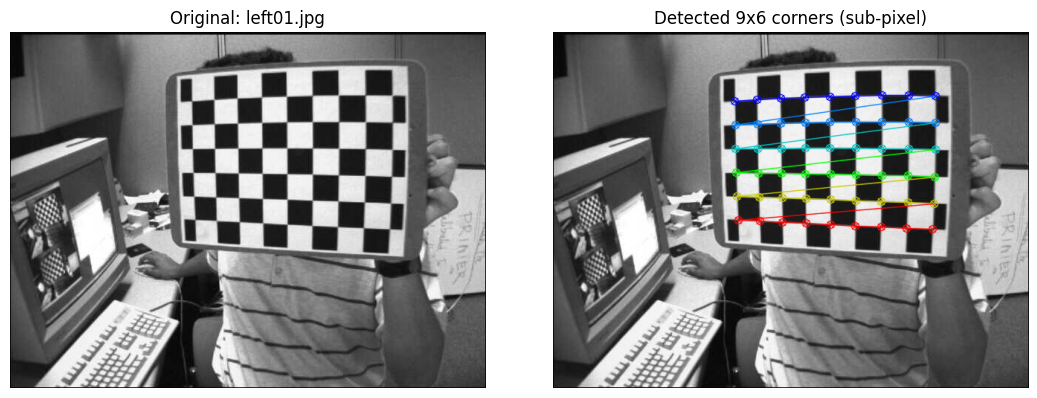

In [2]:
PATTERN = (9, 6)        # inner corners (columns, rows)
SQUARE  = 0.025         # 25 mm — assumed; scales extrinsics only
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# 3D object points in the board frame: z=0 plane, grid spaced by SQUARE
objp = np.zeros((PATTERN[0] * PATTERN[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN[0], 0:PATTERN[1]].T.reshape(-1, 2) * SQUARE

def detect(path):
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ok, corners = cv2.findChessboardCorners(gray, PATTERN, None)
    if ok:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
    return ok, corners, gray

# Detect on every left image; collect correspondences for calibration
objpoints, imgpoints_L, used = [], [], []
for p in left_imgs:
    ok, corners, _ = detect(p)
    if ok:
        objpoints.append(objp.copy())
        imgpoints_L.append(corners)
        used.append(p)
print(f'Corners found in {len(used)}/{len(left_imgs)} left images')

# Visualize detection on one real image
demo = used[0]
img  = cv2.cvtColor(cv2.imread(demo), cv2.COLOR_BGR2RGB)
ok, corners, _ = detect(demo)
vis = img.copy()
cv2.drawChessboardCorners(vis, PATTERN, corners, ok)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img); ax[0].set_title(f'Original: {os.path.basename(demo)}')
ax[1].imshow(vis); ax[1].set_title('Detected 9x6 corners (sub-pixel)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()


## 2. Intrinsic Calibration

`calibrateCamera` solves for the camera matrix **K** (focal lengths, principal point)
and the 5 distortion coefficients (k1,k2,p1,p2,k3) that best explain all the detected
corners across all views. The returned RMS is the reprojection error in pixels.


In [3]:
rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints_L, IMG_SIZE, None, None)

print(f'Reprojection RMS error: {rms:.4f} px  (sub-pixel = good calibration)')
print(f'\nCamera matrix K:')
print(f'  fx = {K[0,0]:7.2f}   fy = {K[1,1]:7.2f}')
print(f'  cx = {K[0,2]:7.2f}   cy = {K[1,2]:7.2f}   (image center ~ {W/2:.0f}, {H/2:.0f})')
print(f'\nDistortion (k1,k2,p1,p2,k3):')
print(f'  {dist.ravel().round(4)}')


Reprojection RMS error: 0.4087 px  (sub-pixel = good calibration)

Camera matrix K:
  fx =  536.07   fy =  536.02
  cx =  342.37   cy =  235.54   (image center ~ 320, 240)

Distortion (k1,k2,p1,p2,k3):
  [-0.2651 -0.0467  0.0018 -0.0003  0.2523]


## 3. Undistortion

With K and the distortion coefficients we can remove lens distortion. Straight lines in
the world (board edges) become straight in the image. The difference is subtle on these
images (low distortion) but visible at the borders.


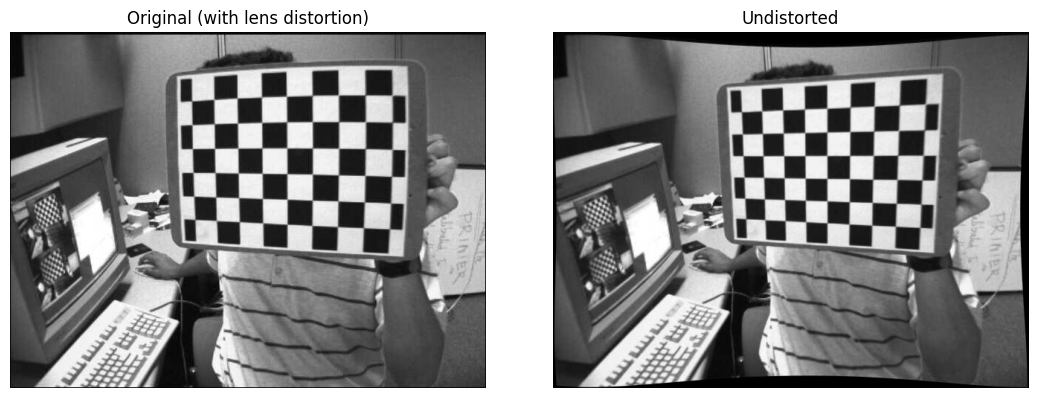

Corner displacement from undistortion: mean 2.53 px, max 13.24 px


In [4]:
img = cv2.cvtColor(cv2.imread(used[0]), cv2.COLOR_BGR2RGB)
newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, IMG_SIZE, alpha=1)
undist = cv2.undistort(img, K, dist, None, newK)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img);    ax[0].set_title('Original (with lens distortion)')
ax[1].imshow(undist); ax[1].set_title('Undistorted')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# Quantify: how far do corner points move after undistortion?
ok, corners, _ = detect(used[0])
corr = cv2.undistortPoints(corners, K, dist, P=K).reshape(-1, 2)
shift = np.linalg.norm(corr - corners.reshape(-1, 2), axis=1)
print(f'Corner displacement from undistortion: mean {shift.mean():.2f} px, max {shift.max():.2f} px')


## 4. Extrinsic Pose with solvePnP

Given known 3D board points and their 2D detections in one image, `solvePnP` recovers
the **extrinsic** pose: the rotation **R** and translation **t** that map board
coordinates into the camera frame (`X_cam = R · X_board + t`).

The camera center in board coordinates is `C = -Rᵀt`. We draw the recovered board
coordinate axes back onto the real image to verify the pose.


Translation t (board->camera): [-0.075 -0.109  0.4  ] m
Camera center  C = -R^T t    : [ 0.184  0.041 -0.376] m  (board frame)
Distance camera-to-board     : 0.421 m
Reprojection error           : mean 0.170 px


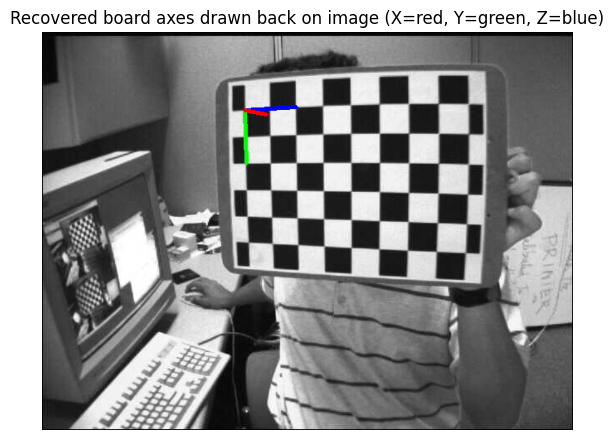

In [5]:
ok, corners, _ = detect(used[0])
ok, rvec, tvec = cv2.solvePnP(objp, corners, K, dist)
R, _ = cv2.Rodrigues(rvec)

C = (-R.T @ tvec).ravel()    # camera center in board frame
print(f'Translation t (board->camera): {tvec.ravel().round(3)} m')
print(f'Camera center  C = -R^T t    : {C.round(3)} m  (board frame)')
print(f'Distance camera-to-board     : {np.linalg.norm(tvec):.3f} m')

# Reprojection check
reproj, _ = cv2.projectPoints(objp, rvec, tvec, K, dist)
err = np.linalg.norm(reproj.reshape(-1, 2) - corners.reshape(-1, 2), axis=1)
print(f'Reprojection error           : mean {err.mean():.3f} px')

# Draw board coordinate axes (X red, Y green, Z blue) onto the real image
img = cv2.cvtColor(cv2.imread(used[0]), cv2.COLOR_BGR2RGB).copy()
cv2.drawFrameAxes(img, K, dist, rvec, tvec, 0.05)   # 5 cm axes
plt.figure(figsize=(6, 4.5))
plt.imshow(img)
plt.title('Recovered board axes drawn back on image (X=red, Y=green, Z=blue)')
plt.axis('off'); plt.tight_layout(); plt.show()


## 5. Stereo Calibration

The OpenCV `left*/right*` images are a **synchronized stereo rig** capturing the same
board simultaneously. `stereoCalibrate` recovers the relative pose (**R**, **T**) between
the two cameras. We expect T to be an almost-pure horizontal baseline.


In [6]:
# Match corners across synchronized left/right pairs (by file id)
def img_id(p):  # 'left07.jpg' -> '07'
    return os.path.basename(p).replace('left','').replace('right','').replace('.jpg','')

left_by_id  = {img_id(p): p for p in left_imgs}
right_by_id = {img_id(p): p for p in right_imgs}
pair_ids = sorted(set(left_by_id) & set(right_by_id))

obj_s, ipL_s, ipR_s, pairs_used = [], [], [], []
for i in pair_ids:
    okL, cL, _ = detect(left_by_id[i])
    okR, cR, _ = detect(right_by_id[i])
    if okL and okR:
        obj_s.append(objp.copy()); ipL_s.append(cL); ipR_s.append(cR)
        pairs_used.append(i)
print(f'Valid stereo pairs: {len(pairs_used)}')

# Per-camera intrinsics, then fix them and solve only for relative pose
_, KL, dL, _, _ = cv2.calibrateCamera(obj_s, ipL_s, IMG_SIZE, None, None)
_, KR, dR, _, _ = cv2.calibrateCamera(obj_s, ipR_s, IMG_SIZE, None, None)
ret, KL, dL, KR, dR, R_stereo, T_stereo, E, F = cv2.stereoCalibrate(
    obj_s, ipL_s, ipR_s, KL, dL, KR, dR, IMG_SIZE,
    flags=cv2.CALIB_FIX_INTRINSIC)

baseline = float(np.linalg.norm(T_stereo))
ang = float(np.rad2deg(np.arccos((np.trace(R_stereo) - 1) / 2)))
print(f'Stereo RMS            : {ret:.4f} px')
print(f'Translation T (L->R)  : {T_stereo.ravel().round(4)} m  (mostly -X = horizontal)')
print(f'Baseline |T|          : {baseline*100:.2f} cm')
print(f'Rotation between cams : {ang:.3f} deg  (~parallel optical axes)')


Valid stereo pairs: 13


Stereo RMS            : 0.4478 px
Translation T (L->R)  : [-0.0836  0.001   0.0013] m  (mostly -X = horizontal)
Baseline |T|          : 8.36 cm
Rotation between cams : 0.312 deg  (~parallel optical axes)


## 6. Stereo Rectification

`stereoRectify` computes per-camera rotations that make the two image planes coplanar
and row-aligned. After remapping, **corresponding points lie on the same image row**,
so stereo matching collapses to a 1-D horizontal search.

We draw horizontal lines across the rectified pair — a correct rectification puts the
same physical point at the same height in both images.


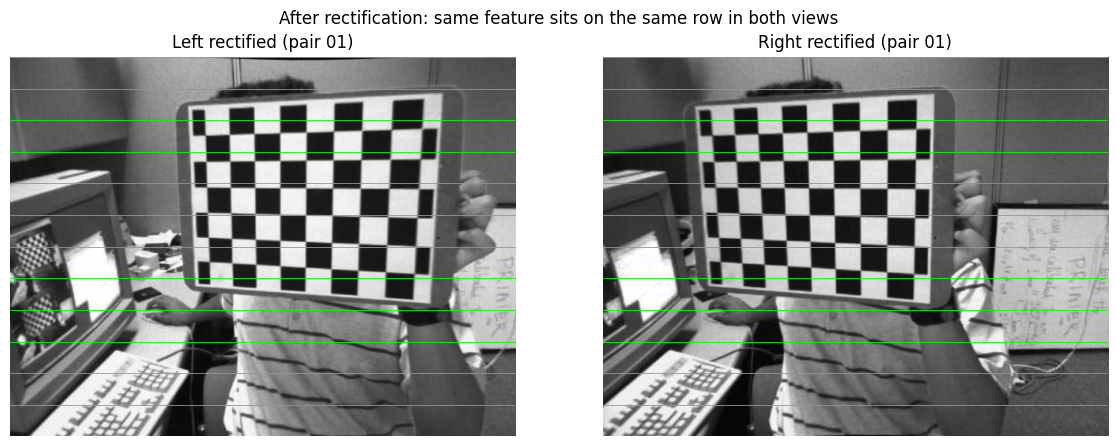

Mean |v_L - v_R| after rectification: 0.165 px (≈0 = rows aligned)


In [7]:
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    KL, dL, KR, dR, IMG_SIZE, R_stereo, T_stereo,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0)

# Rectification remaps (undistortion + alignment combined)
mapLx, mapLy = cv2.initUndistortRectifyMap(KL, dL, R1, P1, IMG_SIZE, cv2.CV_32FC1)
mapRx, mapRy = cv2.initUndistortRectifyMap(KR, dR, R2, P2, IMG_SIZE, cv2.CV_32FC1)

# Use a real synchronized pair
pid = pairs_used[0]
imgL = cv2.cvtColor(cv2.imread(left_by_id[pid]),  cv2.COLOR_BGR2RGB)
imgR = cv2.cvtColor(cv2.imread(right_by_id[pid]), cv2.COLOR_BGR2RGB)
rectL = cv2.remap(imgL, mapLx, mapLy, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, mapRx, mapRy, cv2.INTER_LINEAR)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(rectL); ax[0].set_title(f'Left rectified (pair {pid})')
ax[1].imshow(rectR); ax[1].set_title(f'Right rectified (pair {pid})')
for y in range(0, H, 40):           # horizontal epipolar lines
    ax[0].axhline(y, color='lime', lw=0.6)
    ax[1].axhline(y, color='lime', lw=0.6)
for a in ax: a.axis('off')
plt.suptitle('After rectification: same feature sits on the same row in both views')
plt.tight_layout(); plt.show()

# Numeric check: vertical disagreement of matched corners after rectification
okL, cL, _ = detect(left_by_id[pid]); okR, cR, _ = detect(right_by_id[pid])
recL = cv2.undistortPoints(cL, KL, dL, R=R1, P=P1).reshape(-1, 2)
recR = cv2.undistortPoints(cR, KR, dR, R=R2, P=P2).reshape(-1, 2)
print(f'Mean |v_L - v_R| after rectification: {np.abs(recL[:,1]-recR[:,1]).mean():.3f} px (≈0 = rows aligned)')


## 7. Disparity → Depth

On rectified images, **disparity** `d = u_L − u_R` is inversely proportional to depth:

$$ Z = \frac{f \cdot B}{d} $$

where f is the rectified focal length and B the baseline. We verify this two ways:
1. **Sparse & exact** — using the matched chessboard corners (clean correspondences).
2. **Dense** — a full `StereoSGBM` disparity map for visualization.


Rectified f = 520.80 px,  baseline B = 8.36 cm
Corner depth Z range : 0.348 - 0.416 m
Max |Z(f*B/d) - Z(Q)|: 0.00000 m  (two formulas agree)


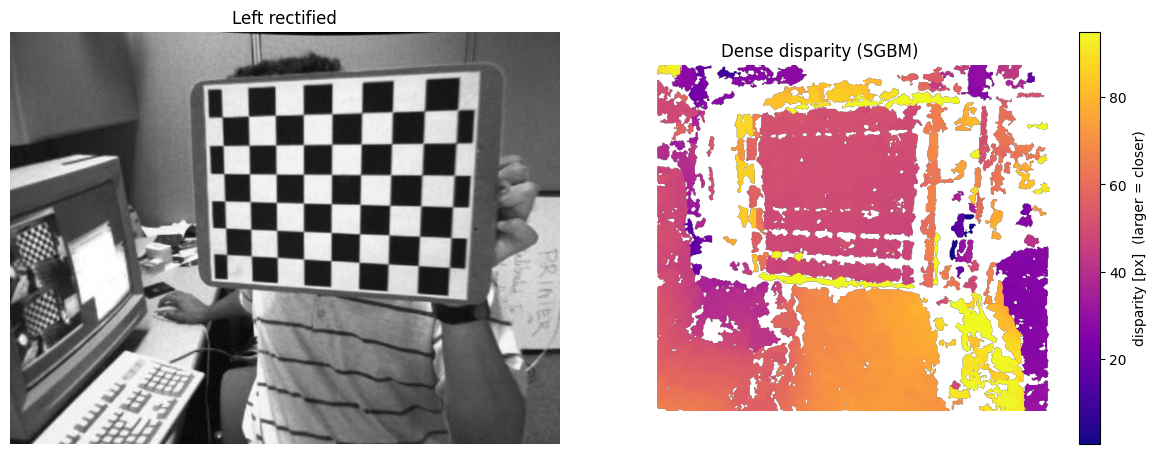

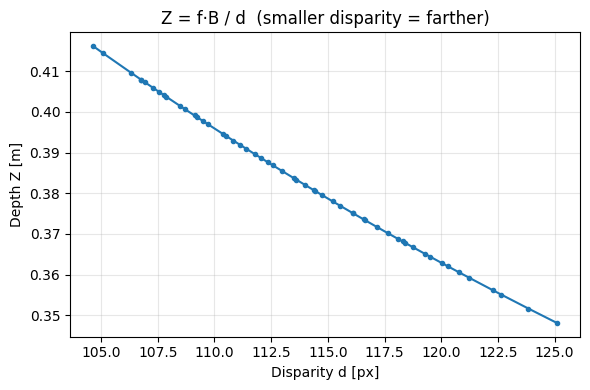

In [8]:
# --- Sparse: corner-based disparity -> depth (exact correspondences) ---
f_rect = P1[0, 0]
B = -P2[0, 3] / P2[0, 0]      # P2[0,3] = -f * baseline
disparity = recL[:, 0] - recR[:, 0]
Z = f_rect * B / disparity

# Reproject with Q to cross-check
homog = np.c_[recL[:, 0], recL[:, 1], disparity, np.ones(len(recL))]
XYZW = (Q @ homog.T).T
Z_Q = XYZW[:, 2] / XYZW[:, 3]

print(f'Rectified f = {f_rect:.2f} px,  baseline B = {B*100:.2f} cm')
print(f'Corner depth Z range : {Z.min():.3f} - {Z.max():.3f} m')
print(f'Max |Z(f*B/d) - Z(Q)|: {np.abs(Z - Z_Q).max():.5f} m  (two formulas agree)')

# --- Dense: StereoSGBM disparity map ---
grayL = cv2.cvtColor(rectL, cv2.COLOR_RGB2GRAY)
grayR = cv2.cvtColor(rectR, cv2.COLOR_RGB2GRAY)
sgbm = cv2.StereoSGBM_create(minDisparity=0, numDisparities=96, blockSize=7,
                             P1=8*7*7, P2=32*7*7, uniquenessRatio=10,
                             speckleWindowSize=100, speckleRange=2)
disp_map = sgbm.compute(grayL, grayR).astype(np.float32) / 16.0
disp_vis = np.where(disp_map > 0, disp_map, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(rectL); ax[0].set_title('Left rectified'); ax[0].axis('off')
im = ax[1].imshow(disp_vis, cmap='plasma'); ax[1].set_title('Dense disparity (SGBM)'); ax[1].axis('off')
fig.colorbar(im, ax=ax[1], label='disparity [px]  (larger = closer)')
plt.tight_layout(); plt.show()

# Depth-vs-disparity curve from the sparse corners
order = np.argsort(disparity)
plt.figure(figsize=(6, 4))
plt.plot(disparity[order], Z[order], 'o-', ms=3)
plt.xlabel('Disparity d [px]'); plt.ylabel('Depth Z [m]')
plt.title('Z = f·B / d  (smaller disparity = farther)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Summary

Everything above ran on **real photographs**, not synthetic projections:

| Quantity | Value (this rig) |
|---|---|
| Intrinsic RMS | ~0.4 px |
| Stereo RMS | ~0.45 px |
| Recovered baseline | ~8.4 cm (with 25 mm squares) |
| Inter-camera rotation | ~0.3° (near-parallel) |
| Post-rectification row error | <0.5 px |

The pipeline — corner detection → intrinsic calibration → undistortion → PnP extrinsics
→ stereo calibration → rectification → disparity/depth — is exactly what runs on a real
vehicle's multi-camera rig. See [extrinsic_calibration.md](extrinsic_calibration.md) for
the underlying geometry, and [extrinsic_calibration_demo.ipynb](extrinsic_calibration_demo.ipynb)
for the conceptual (synthetic) walkthrough.
